# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 7: Mixture Models

Topics covered 
 - Fitting Gaussian Mixture models using the EM algorithm
 - Obtaining information on soft allocation of individuals
 - Model Choice within the family of Gaussian Mixtures
 - Bayesian approach with overfitted mixtures

Standaer libraries will be used with the addition of two new ones from sklearn for the EM and Variational Bayes approach on Gaussian Mixtures

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np

from sklearn import datasets
#The next two lines import the functions for the two things we will look into today
from sklearn.mixture import GaussianMixture
from sklearn.mixture import BayesianGaussianMixture

### Load the Iris dataset

The Iris Dataset. This data sets consists of 3 different types of irises' (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 numpy.ndarray. The rows being the samples and the columns being: Sepal Length, Sepal Width, Petal Length and Petal Width. The below plot uses the first two features.

In [2]:
iris = datasets.load_iris()
#next we import it into a pandas frame for convenience (not necessry)
pdiris = pd.DataFrame(iris.data, columns=iris.feature_names)
print(pdiris.shape)
pdiris.head()

(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Plots 

Below we will see some 2d plots just to get a feel of the data. There appears to be some clustering but it is hard to infer the number of clusters of the 4d datasets from 2d plots. 

Text(0, 0.5, 'petal length (cm)')

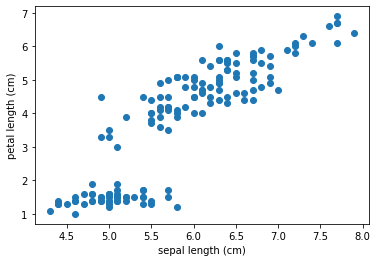

In [3]:
plt.plot(pdiris['sepal length (cm)'], pdiris['petal length (cm)'], 'o')
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

Text(0, 0.5, 'petal width (cm)')

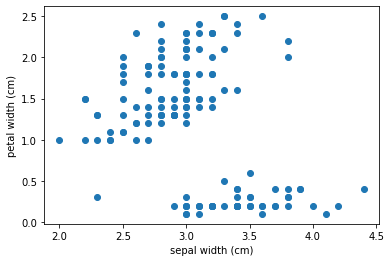

In [4]:
plt.plot(pdiris['sepal width (cm)'], pdiris['petal width (cm)'], 'o')
plt.xlabel('sepal width (cm)')
plt.ylabel('petal width (cm)')

### Fitting GMMs using the EM algorithm

The code for doing so is given below. The '.fit' bit obtains the MLEs of means and covariances that can be viewed using '.means_' and '.covariances_'

We start by inspecting and visualisibg a 2-d dataset with only the 'sepal width (cm)' and 'petal width (cm)' variables. The full dataset is analysed afterwards

We assume a Gaussian mixture model with $K=2$ components. Introduce a latent variable $z_i \in \{1,2\}$ indicating which mixture component generates $x_i$.
The model is
$$
\mathbb{P}(z_i = k) = \pi_k, \qquad k=1,2,
$$
with
$$
\pi_k \ge 0, \qquad \sum_{k=1}^2 \pi_k = 1.
$$

Conditional on $z_i = k$, we assume
$$
x_i \mid z_i = k \sim \mathcal{N}(\mu_k,\Sigma_k), \qquad k=1,2.
$$

In [ ]:
vars = ['sepal width (cm)','petal width (cm)']
gmm = GaussianMixture(n_components=2)
gmm.fit(pdiris[vars])
print(gmm.means_)
print('\n')
print(gmm.covariances_)

### Soft allocation of individuals to clusters

GMM method does not necesarily allocates individuals with certainty but with probabilities.

Adding the probabilities can give as an ideas of how many people each cluster has.

In [ ]:
probs = gmm.predict_proba(pdiris[vars])  # Compute posterior probabilities (responsibilities): gamma_ik
print(np.sum(probs,axis=0))  # The number of samples assigned to each component
print(probs[21:50].round(3))  

### Model Search

We need to fit models wiht different numbers of cluster and different type of covariance matrices to identify the best one. This is done via the BIC (the smaller the better in this case)

Types of covariance matrices:
 - spherical: each cluster k has covariance $\sigma^2_k I$
 - tied: full covariance matrix but the same across clusters
 - diag: diagonal covariance matrix, different for each cluster
 - full: full covariance matrix, different for each cluster
 

In [ ]:
lowest_bic = np.inf

#Consider k=1,...,8 and four types of covariance matrix
n_components_range = range(1, 9)
cv_types = ['spherical', 'tied', 'diag', 'full']  # different types of covariance matrix
bic = np.zeros((len(n_components_range),len(cv_types))) #matrix to store the BICs
j = -1
for cv_type in cv_types:
    j = j+1
    for n_components in n_components_range:
        # Fit a Gaussian mixture with EM
        gmm = GaussianMixture(n_components=n_components,
                                      covariance_type=cv_type)
        gmm.fit(pdiris)
        bicij = gmm.bic(pdiris)  #get the BIC 
        bic[n_components-1,j] = bicij
        #the code below keeps track of the model with the lowest BIC
        if bicij < lowest_bic:
            lowest_bic = bicij
            best_gmm = gmm
print(lowest_bic)
bic = pd.DataFrame(bic,columns = cv_types,index=n_components_range)
bic

In [ ]:
print(best_gmm.means_)
print('\n')
print(best_gmm.covariances_)

1. **Spherical**  
   $$
   \Sigma_k = \sigma_k^2 I_d
   $$

2. **Tied**  
   $$
   \Sigma_1=\Sigma_2=\cdots=\Sigma_K=\Sigma
   $$

3. **Diag**  
   $$
   \Sigma_k = \mathrm{diag}(\sigma_{k1}^2,\dots,\sigma_{kd}^2)
   $$

4. **Full**  
   $$
   \Sigma_k \in \mathbb{R}^{d\times d}
   $$

### Activity 1

Repeat the analysis using only two of the four variables. Do we get a different conclusion on the number of clusters? 

Put your code below

### Simulate data to test the method

So far we have been looking at a dataset where we are not sure about the 'true' number of clusters and type of covariance matrix.

In what follows we will simulate data from a Gaussian mixture with three components and spherical covariance matrix.

(600, 2)
[[-5.98898996  2.96813929]
 [-0.05362383  0.10657981]
 [ 3.30233239 -3.6440943 ]]
[0.15235684 0.95059212 9.1307105 ]


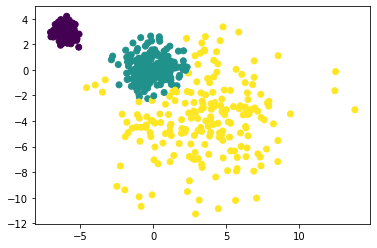

In [5]:
# Number of samples per component
n_samples = 200
np.random.seed(5)

# Generate random sample, three components 
# 1.mean (0,0) cov=1 I, 
# 2. mean (-6, 3) cov=.16 I and
# 3. mean (3, -4) cov=9 I
X = np.r_[np.random.randn(n_samples, 2), 
          .4 * np.random.randn(n_samples, 2) + np.array([-6, 3]), 
         3* np.random.randn(n_samples, 2) + np.array([3, -4])] 
print(X.shape)
gmm = GaussianMixture(n_components=3,covariance_type='spherical')
gmm.fit(X)
print(gmm.means_)
print(gmm.covariances_)
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels)                                                     

In [6]:
probs = gmm.predict_proba(X)
print(np.sum(probs,axis=0))
print(probs[400:599].round(3))

[199.89156044 191.65931888 208.44912068]
[[0.    0.924 0.076]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.573 0.427]
 [0.    0.    1.   ]
 [0.    0.124 0.876]
 [0.    0.965 0.035]
 [0.    0.972 0.028]
 [0.    0.    1.   ]
 [0.    0.786 0.214]
 [0.    0.    1.   ]
 [0.    0.844 0.156]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.003 0.997]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.954 0.046]
 [0.    0.    1.   ]
 [0.    0.566 0.434]
 [0.    0.002 0.998]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.167 0.833]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.002 0.998]
 [0.    0.001 0.999]
 [0.    0.015 0.985]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.346 0.654]
 [0.    0.322 

### Test the method

Below we repeat the previous model search procedure to the data contained in X. We would like to test whethere the optimal models will indeed be the one with three components and spherical covariance

In [7]:
lowest_bic = np.inf
n_components_range = range(1, 9)
cv_types = ['spherical', 'tied', 'diag', 'full']
bic = np.zeros((len(n_components_range),len(cv_types)))
j = -1
for cv_type in cv_types:
    j = j+1
    for n_components in n_components_range:
        # Fit a Gaussian mixture with EM
        gmm = GaussianMixture(n_components=n_components,
                                      covariance_type=cv_type)
        gmm.fit(X)
        bicij = gmm.bic(X)
        bic[n_components-1,j] = bicij
        if bicij < lowest_bic:
            lowest_bic = bicij
            best_gmm = gmm
print(lowest_bic)
bic = pd.DataFrame(bic,columns = cv_types,index=n_components_range)
bic

c:\Users\19175\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\19175\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\19175\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\19175\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows wi

4814.519577703147


,spherical,tied,diag,full
1,6652.518333,6184.196737,6615.417378,6184.196737
2,5157.619530,6153.896995,5168.246038,5122.187996
3,4814.519578,5836.898265,4830.568268,4849.788586
4,4841.296848,5716.420978,4864.335123,4888.753587
5,4868.646465,5580.350885,4894.067730,4916.812423
6,4892.547636,5557.355057,4913.395633,4944.151711
7,4906.099337,5575.942656,4945.353047,4975.342213
8,4928.656350,5536.174658,4966.219007,4996.325102


### Activity 2

Conduct another simulation experiment generating data from a Gaussian mixture. Choose your own number of components, means and covariances.

Put your code below

(800, 2)
[[ 3.33786321 -3.95381328]
 [ 2.94081998  2.77592852]
 [-5.98883526  2.96793059]
 [-0.0887763   0.06948606]]
[8.77218242 0.96656183 0.1525247  0.93193251]


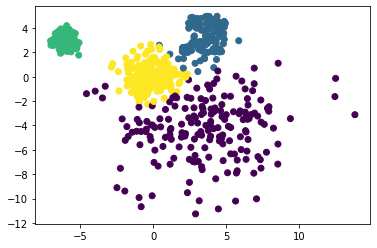

In [24]:
# Number of samples per component
n_samples = 200
np.random.seed(5)

# Generate random sample, three components 
# 1.mean (0,0) cov=1 I, 
# 2. mean (-6, 3) cov=.16 I and
# 3. mean (3, -4) cov=9 I
# 4. mean(2,2) cov=(3,1) I
X = np.r_[np.random.randn(n_samples, 2), 
          .4 * np.random.randn(n_samples, 2) + np.array([-6, 3]), 
         3* np.random.randn(n_samples, 2) + np.array([3, -4]),
         np.reshape(np.hstack((3*np.random.random(n_samples) + 2, 0.4*np.random.random(n_samples) + 2)),(n_samples,2))]
print(X.shape)
gmm = GaussianMixture(n_components=4,covariance_type='spherical')
gmm.fit(X)
print(gmm.means_)
print(gmm.covariances_)
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels)                                                     

## Overfitted (Bayesian) Gaussian Mixtures

Now we will explore what happens when we fit a model with more components than the ones in the data. 

In [25]:
gmm = GaussianMixture(n_components=6,covariance_type='spherical')
gmm.fit(X)
probs = gmm.predict_proba(X)
results = np.sum(probs,axis=0)
results = pd.DataFrame(results.round(0), columns = ['# of individuals'], index=range(1,7))
results

,# of individuals
1,105.0
2,200.0
3,116.0
4,201.0
5,103.0
6,76.0


In [ ]:
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels) 

We will also apply the fully Bayesian model to the same data with a Dirichlet prior on the cluster probabilities with a low hyperparameter (weight_concentration_prior) of 0.01. This choice is going to penalise redundant clusters by not allocating individuals to them unless it is necessaray 

### Latent component labels
For each observation $x_i$, introduce a latent variable $z_i \in \{1,\dots,K\}$:
$$
z_i \mid \pi \sim \mathrm{Categorical}(\pi_1,\dots,\pi_K), \qquad i=1,\dots,n.
$$

### Observation model
Conditional on the component label $z_i=k$,
$$
x_i \mid (z_i=k,\mu_k,\Sigma_k) \sim \mathcal{N}(\mu_k,\Sigma_k).
$$

### Prior on mixture weights
The mixture weights are given a Dirichlet prior:
$$
\pi = (\pi_1,\dots,\pi_K) \sim \mathrm{Dirichlet}(\alpha_1,\dots,\alpha_K).
$$

A common symmetric choice is
$$
\pi \sim \mathrm{Dirichlet}(\alpha,\dots,\alpha).
$$

When $\alpha$ is small (e.g. $\alpha=0.01$), the prior encourages sparse mixture weights, so redundant components tend to have weights close to zero.

### Marginal mixture density
Hence, the marginal density of $x_i$ is
$$
p(x_i \mid \pi,\mu,\Sigma)
=
\sum_{k=1}^K \pi_k \,\mathcal{N}(x_i \mid \mu_k,\Sigma_k).
$$

### Key idea
Compared with a standard GMM, a Bayesian GMM places priors on the parameters (especially on $\pi$), which helps regularise the model and can automatically suppress unnecessary components.

In [ ]:
Bgmm = BayesianGaussianMixture(n_components=6,covariance_type='full',
                               weight_concentration_prior=0.01, max_iter = 200)  # alpha = 0.01
Bgmm.fit(X)
probs = Bgmm.predict_proba(X)
results = np.sum(probs,axis=0)
results = pd.DataFrame(results.round(0), columns = ['# of individuals'], index=range(1,7))
results

In [ ]:
labels = Bgmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels)

## LDA generative model
LDA aims to discover a small set of latent topics (each a distribution over words) from a corpus, and represent each document as a mixture of these topics by learning the topic--word distributions $\{\phi_k\}$ and the document--topic proportions $\{\theta_d\}$.

### Indices and sizes
- $d \in \{1,\dots,D\}$: document index (there are $D$ documents)
- $n \in \{1,\dots,N_d\}$: token position index within document $d$ (document $d$ has $N_d$ tokens)
- $k \in \{1,\dots,K\}$: topic index (there are $K$ topics)
- $v \in \{1,\dots,V\}$: vocabulary (word type) index (vocabulary size $V$)

---

### Random variables and parameters
- $\theta_d \in \Delta^{K-1}$: **document-topic proportions** for document $d$  
  $$\theta_d = (\theta_{d1},\dots,\theta_{dK}), \quad \theta_{dk}\ge 0,\ \sum_{k=1}^K \theta_{dk}=1$$  
  Here $\theta_{dk}$ is the probability that a random token in document $d$ uses topic $k$.

- $\phi_k \in \Delta^{V-1}$: **topic-word distribution** for topic $k$  
  $$\phi_k = (\phi_{k1},\dots,\phi_{kV}), \quad \phi_{kv}\ge 0,\ \sum_{v=1}^V \phi_{kv}=1$$  
  Here $\phi_{kv}$ is the probability of word type $v$ under topic $k$.

- $z_{dn} \in \{1,\dots,K\}$: **topic assignment** of token $n$ in document $d$.  
  The event $z_{dn}=k$ means “token $n$ in document $d$ is generated from topic $k$”.

- $w_{dn} \in \{1,\dots,V\}$: **observed word type index** of token $n$ in document $d$.  
  The event $w_{dn}=v$ means “the observed token is the vocabulary item $v$”.

- $\alpha \in \mathbb{R}_{+}^{K}$: Dirichlet hyperparameter for document-topic proportions  
  $$\alpha = (\alpha_1,\dots,\alpha_K), \quad \alpha_k>0$$

- $\beta \in \mathbb{R}_{+}^{V}$: Dirichlet hyperparameter for topic-word distributions  
  $$\beta = (\beta_1,\dots,\beta_V), \quad \beta_v>0$$

---

### Generative process
1. **Draw document-topic proportions** for each document $d$:
$$\theta_d \sim \mathrm{Dirichlet}(\alpha).$$

2. **Draw topic-word distributions** for each topic $k$:
$$\phi_k \sim \mathrm{Dirichlet}(\beta).$$

3. For each token position $n=1,\dots,N_d$ in document $d$:
   - **Choose a topic**:
$$z_{dn}\mid \theta_d \sim \mathrm{Categorical}(\theta_d),
\quad\text{i.e.}\quad
\Pr(z_{dn}=k\mid \theta_d)=\theta_{dk}.$$

   - **Choose a word given the topic**:
$$w_{dn}\mid z_{dn},\{\phi_k\}_{k=1}^K \sim \mathrm{Categorical}(\phi_{z_{dn}}),
\quad\text{i.e.}\quad
\Pr(w_{dn}=v\mid z_{dn}=k)=\phi_{kv}.$$

---

### Intuition
- $\theta_d$: how much each topic appears in document $d$.  
- $\phi_k$: which words topic $k$ tends to use.  
- $z_{dn}$: which topic generated token $n$ in document $d$.  
- $w_{dn}$: the actual observed word at that token.

## Mean-field Variational Bayes (VB) for LDA (how it works)

### Goal
We want the posterior $p(\theta,z,\phi\mid w)$, but it is intractable.  
VB approximates it with a simpler distribution $q(\theta,z,\phi)$ by maximizing the ELBO.

---

### Mean-field factorization
Assume a fully factorized variational family:
$$
q(\theta,z,\phi)=\prod_{d=1}^D q(\theta_d;\gamma_d)\;
\prod_{n=1}^{N_d} q(z_{dn};\omega_{dn})\;
\prod_{k=1}^K q(\phi_k;\lambda_k).
$$

Where
- $q(\theta_d)$ is Dirichlet: $q(\theta_d)=\mathrm{Dirichlet}(\gamma_d)$ with $\gamma_d\in\mathbb{R}_+^K$,
- $q(z_{dn})$ is Categorical: $q(z_{dn}=k)=\omega_{dnk}$ with $\sum_k \omega_{dnk}=1$,
- $q(\phi_k)$ is Dirichlet: $q(\phi_k)=\mathrm{Dirichlet}(\lambda_k)$ with $\lambda_k\in\mathbb{R}_+^V$.

---

### ELBO (objective)
VB chooses $q$ by maximizing
$$
\mathcal{L}(q)=\mathbb{E}_q[\log p(w,\theta,z,\phi)]-\mathbb{E}_q[\log q(\theta,z,\phi)].
$$

---

### Coordinate-ascent VB updates (core idea)
Repeat until convergence:

#### 1) Update token responsibilities (soft topic assignment)
For each document $d$ and token $n$:
$$
\omega_{dnk}\propto \exp\Big(\mathbb{E}_q[\log \theta_{dk}] + \mathbb{E}_q[\log \phi_{k,w_{dn}}]\Big),
\qquad \text{then normalize over }k.
$$

The needed expectations under Dirichlet are:
$$
\mathbb{E}_q[\log \theta_{dk}] = \psi(\gamma_{dk})-\psi\Big(\sum_{j=1}^K \gamma_{dj}\Big),
$$
$$
\mathbb{E}_q[\log \phi_{kv}] = \psi(\lambda_{kv})-\psi\Big(\sum_{u=1}^V \lambda_{ku}\Big).
$$

#### 2) Update document-topic Dirichlet parameters
For each document $d$ and topic $k$:
$$
\gamma_{dk}=\alpha_k+\sum_{n=1}^{N_d}\omega_{dnk}.
$$

#### 3) Update topic-word Dirichlet parameters
For each topic $k$ and vocabulary word $v$:
$$
\lambda_{kv}=\beta_v+\sum_{d=1}^D\sum_{n=1}^{N_d}\omega_{dnk}\,\mathbf{1}[w_{dn}=v].
$$

---

### Interpretation
- $\omega_{dnk}$: “how much token $(d,n)$ belongs to topic $k$” (soft assignment)  
- $\gamma_{dk}$: prior $\alpha_k$ + expected topic counts in document $d$  
- $\lambda_{kv}$: prior $\beta_v$ + expected counts of word $v$ in topic $k$

## LDA 
1. Load a small real text corpus (20 Newsgroups, 4 categories).
2. Fit **Variational Bayes LDA** using scikit-learn.
3. Inspect **topics** (top words) and **document-topic proportions**.
4. Connect to **overfitted mixtures**: fit with large `K` and set small Dirichlet hyperparameter `α` to discourage tiny/unused components.

In [26]:
### 1) Load a small, interpretable subset of 20 Newsgroups
from sklearn.datasets import fetch_20newsgroups

RANDOM_STATE = 0 # Reproducibility
cats = ["talk.politics.misc", "rec.sport.baseball", "sci.space", "comp.graphics"] # choose 4 categories (sub-corpora) from 20 Newsgroups
data = fetch_20newsgroups(subset="train", categories=cats, remove=("headers","footers","quotes")) # remove email headers/footers/quoted replies to reduce noise

len(data.data), set(data.target_names)

(2239,
 {'comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc'})

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

vec = CountVectorizer(
    max_df=0.6,  # drop words that appear in >60% of documents (too common, low information)
    min_df=10,  # drop words that appear in <10 documents (too rare)
    stop_words="english"  # remove common English stop words (e.g., "the", "and", "is")
)
X = vec.fit_transform(data.data) # learn the vocabulary from the corpus and transform documents into a sparse (D x V) count matrix
vocab = np.array(vec.get_feature_names_out()) # get the vocabulary list: vocab[j] is the word for column j in X
X.shape

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names_out'

### Function to fit LDA and print topics

`LatentDirichletAllocation` in scikit-learn uses **variational Bayes**.  
We’ll print the top words per topic and some diagnostics about topic usage.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

def fit_lda_and_summarise(X, vocab, K=6, alpha=0.1, beta=0.01, topn=10, random_state=0):
    lda = LatentDirichletAllocation(
        n_components=K,                 # number of topics
        learning_method="batch",        # deterministic batch VB updates (uses full dataset each iteration)
        doc_topic_prior=alpha,          # Dirichlet prior for document-topic proportions (θ)
        topic_word_prior=beta,          # Dirichlet prior for topic-word distributions (φ)
        random_state=random_state
    )
    Theta = lda.fit_transform(X)  # (D x K) approximate posterior doc-topic proportions
    Phi = lda.components_ / lda.components_.sum(axis=1, keepdims=True)  # (K x V) topic-word probabilities

    print(f"K={K}, alpha={alpha}, beta={beta}")
    print("-"*60)
    for k in range(K):
        top_words = vocab[np.argsort(Phi[k])[-topn:][::-1]]
        print(f"Topic {k:02d}: " + ", ".join(top_words))

    # Topic usage diagnostic: total mass assigned to each topic across all documents
    usage = Theta.sum(axis=0)
    usage = usage / usage.sum()
    print("\nTopic usage (normalised):")
    for k, u in enumerate(usage):
        print(f"  topic {k:02d}: {u:.3f}")
    print("\n# effectively used topics (usage > 0.02):", int((usage > 0.02).sum()))

    return lda, Theta, Phi, usage

### Baseline fit

Start with a modest number of topics.

In [ ]:
lda, Theta, Phi, usage = fit_lda_and_summarise(X, vocab, K=20, alpha=0.1, beta=0.01, topn=10, random_state=RANDOM_STATE)

K=6, alpha=0.1, beta=0.01
------------------------------------------------------------
Topic 00: 00, 10, 02, 03, 01, 000, won, 12, 04, 15
Topic 01: mr, don, know, think, president, just, going, said, like, did
Topic 02: year, good, think, game, team, don, like, just, better, hit
Topic 03: people, government, just, think, time, like, new, make, work, don
Topic 04: image, graphics, edu, file, software, jpeg, files, images, use, ftp
Topic 05: space, nasa, launch, data, earth, orbit, satellite, shuttle, lunar, information

Topic usage (normalised):
  topic 00: 0.071
  topic 01: 0.178
  topic 02: 0.208
  topic 03: 0.197
  topic 04: 0.226
  topic 05: 0.120

# effectively used topics (usage > 0.02): 6


- `Topic 00` ~ `Topic 05`: each line lists the **top 10 highest-probability words** for that topic (used to interpret/name the topic).
  - `Topic 05` is clearly **space** (space, nasa, orbit, ...).
  - `Topic 04` is clearly **graphics/computer graphics** (image, jpeg, files, ...).
  - `Topic 03` is mostly **politics/government discussion** (people, government, ...).
  - `Topic 02` is mostly **game discussion** (game, team, ...).
  - `Topic 01` looks like **general chat mixed with political words** (mr, president, said, ...).
  - `Topic 00` is likely **noise / leftover stopwords / number-like tokens** (00, 10, 02, ...).

- `Topic usage (normalised)` is each topic’s **overall proportion in the whole corpus** (sums to 1). A larger value means the topic is used more across documents. Here `Topic 04` is the largest (0.226), followed by `Topic 02/03/01`.

- `effectively used topics = 6` means **all 6 topics are meaningfully used** (each has usage > 2%), so there are no “empty” topics.

### Overfitted-mixture analogue

In overfitted finite mixtures, we can set **K larger than needed** and use a **small Dirichlet hyperparameter** to discourage tiny components.

In LDA, `doc_topic_prior = α` controls how concentrated each document’s topic mixture is:
- smaller `α` → fewer active topics per document (sparser mixtures)
- in practice, with large `K`, some topics may become **rarely used** (low total posterior mass)

Try increasing `K` and reducing `α`.

In [ ]:
# Overfitted setting: bigger K
lda_big, Theta_big, Phi_big, usage_big = fit_lda_and_summarise(
    X, vocab, K=20, alpha=0.02, beta=0.01, topn=10, random_state=RANDOM_STATE
)

K=20, alpha=0.02, beta=0.01
------------------------------------------------------------
Topic 00: 00, 10, 000, 12, 15, 11, 14, 20, 13, 18
Topic 01: use, insurance, drugs, like, health, people, drug, make, private, canada
Topic 02: software, gun, jewish, heard, like, blacks, little, long, control, old
Topic 03: government, billion, people, tax, like, federal, power, want, money, law
Topic 04: bit, like, use, don, line, does, screen, program, problem, using
Topic 05: space, nasa, launch, shuttle, satellite, mission, orbit, satellites, earth, commercial
Topic 06: mr, president, think, going, know, don, people, jobs, said, did
Topic 07: war, lunar, new, south, military, nuclear, surface, world, time, power
Topic 08: graphics, data, april, information, search, league, tom, anti, group, said
Topic 09: people, work, just, don, like, think, want, young, things, make
Topic 10: earth, orbit, universe, sun, theory, mass, new, space, suck, cubs
Topic 11: image, data, jpeg, images, available, ftp,

## Activity 3

1. Fix `K=10`. Compare `α ∈ {0.01, 0.1, 1.0}` and report:
   - top words for 2 topics you find most interpretable,
   - number of effectively used topics (usage > 0.02).

2. Fix `α=0.05`. Compare `K ∈ {5, 10, 20}`.

3. Optional: change `β` (topic-word prior). Discuss how it changes the *sharpness* of topic word distributions.

Put your code below

- Smaller $\beta$ (e.g. $\beta=0.001$): the topic--word distributions are **sharper / sparser**.  
  Intuition: each topic tends to be dominated by fewer words, so the top words are more concentrated and representative, making topics easier to interpret and name.

- Larger $\beta$ (e.g. $\beta=0.1$): the topic--word distributions are **flatter / more uniform**.  
  Intuition: probability mass is spread across more words, so the top words are more likely to include common/generic terms, and topic boundaries become less clear.

From the outputs:
- The most interpretable topics are broadly consistent across $\beta$ (e.g. Topic 05 remains *space* and Topic 04 remains *graphics*), suggesting the overall topic structure is stable.
- The number of effectively used topics (usage $>0.02$) is $10$ in all three cases, so changing $\beta$ does not create empty topics; it mainly affects the **within-topic concentration** (sharpness) rather than whether topics are used.